In [159]:
# all imports here
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [160]:
df = pd.read_csv("loan_dataset.csv")

# Convert data types
df = df.drop(columns=['application_date', 'application_year'])
df['loan_default'] = df['loan_default'].astype(bool)
df.dtypes

age                       int64
income                  float64
credit_score              int64
loan_amount             float64
debt_to_income_pct      float64
num_dependents          float64
years_employed          float64
account_balance         float64
num_prev_loans            int64
monthly_expenses        float64
gender                      str
employment_status           str
education_level             str
loan_purpose                str
region                      str
marital_status              str
loan_duration_months      int64
loan_default               bool
dtype: object

In [161]:
X = df.drop('loan_default', axis=1)
y = df['loan_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [162]:
#fill missing values with median for numeric columns
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[numeric_cols] = X_train[numeric_cols].fillna(X_train[numeric_cols].median())
X_test[numeric_cols] = X_test[numeric_cols].fillna(X_train[numeric_cols].median())

#fill missing values with "Unknown" for categorical columns
categorical_cols = X_train.select_dtypes(include=['str', 'datetime64']).columns
X_train[categorical_cols] = X_train[categorical_cols].fillna('Unknown')
X_test[categorical_cols] = X_test[categorical_cols].fillna('Unknown')

In [163]:
def apply_binning(df):
    df = df.copy()
    
    df['credit_category'] = pd.cut(
        df['credit_score'],
        bins=[0, 580, 670, 740, 850],
        labels=['Poor', 'Fair', 'Good', 'Very Good'],
        include_lowest=True
    )
    
    df['debt_to_income_category'] = pd.cut(
        df['debt_to_income_pct'],
        bins=[0, 36, 42, 50, 100],
        labels=['Low Risk', 'Manageable', 'High Risk', 'Too Risky'],
        include_lowest=True
    )
    
    return df

X_train = apply_binning(X_train)
X_test = apply_binning(X_test)


In [164]:
X_train.isnull().sum()
X_test.isnull().sum()

age                        0
income                     0
credit_score               0
loan_amount                0
debt_to_income_pct         0
num_dependents             0
years_employed             0
account_balance            0
num_prev_loans             0
monthly_expenses           0
gender                     0
employment_status          0
education_level            0
loan_purpose               0
region                     0
marital_status             0
loan_duration_months       0
credit_category            0
debt_to_income_category    0
dtype: int64

In [ ]:
def add_features(df):
    df = df.copy()

    # avoid divide-by-zero
    income_safe = df["income"].replace(0, np.nan)
    balance_safe = df["account_balance"].replace(0, np.nan)

    # core financial ratios
    df["expense_ratio"] = df["monthly_expenses"] / income_safe
    df["savings_ratio"] = df["account_balance"] / income_safe
    df["loan_ratio"] = df["loan_amount"] / income_safe

    # strong interaction features
    df["financial_stress"] = df["debt_to_income_pct"] * df["expense_ratio"]
    df["loan_to_balance"] = df["loan_amount"] / (df["account_balance"] + 1)
    df["remaining_income"] = df["income"] - df["monthly_expenses"]

    # binary risk flags - very useful for DT
    df["high_risk_flag"] = ((df["credit_score"] < 600) & (df["debt_to_income_pct"] > 0.5)).astype(int)
    df["low_liquidity"] = (df["account_balance"] < df["monthly_expenses"]).astype(int)
    df["poor_credit"] = (df["credit_score"] < 580).astype(int)
    df["severe_debt"] = (df["debt_to_income_pct"] > 0.6).astype(int)
    df["negative_cashflow"] = (df["monthly_expenses"] > df["income"]).astype(int)
    df["extreme_risk"] = ((df["credit_score"] < 580) & (df["loan_ratio"] > 0.5)).astype(int)
    df["financial_pressure"] = ((df["expense_ratio"] > 0.7) & (df["debt_to_income_pct"] > 0.5)).astype(int)

    # replace inf/nan from ratio creation
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)

    return df

X_train = add_features(X_train)
X_test = add_features(X_test)

In [166]:
#Log transformation for skewed features
log_transformer = FunctionTransformer(np.log1p)

X_train[["income", "account_balance", "loan_amount"]] = log_transformer.fit_transform(
    X_train[["income", "account_balance", "loan_amount"]]
)

X_test[["income", "account_balance", "loan_amount"]] = log_transformer.transform(
    X_test[["income", "account_balance", "loan_amount"]]
)


In [167]:
X_train.isnull().sum()
X_test.isnull().sum()

age                        0
income                     0
credit_score               0
loan_amount                0
debt_to_income_pct         0
num_dependents             0
years_employed             0
account_balance            0
num_prev_loans             0
monthly_expenses           0
gender                     0
employment_status          0
education_level            0
loan_purpose               0
region                     0
marital_status             0
loan_duration_months       0
credit_category            0
debt_to_income_category    0
expense_ratio              0
savings_ratio              0
loan_ratio                 0
financial_stress           0
loan_to_balance            0
remaining_income           0
high_risk_flag             0
low_liquidity              0
poor_credit                0
severe_debt                0
negative_cashflow          0
extreme_risk               0
financial_pressure         0
dtype: int64

In [168]:
#One-hot encoding for categorical variables + binned variables
X_train = pd.get_dummies(
    X_train,
    columns=[
        'gender', 'employment_status', 'education_level',
        'loan_purpose', 'region', 'marital_status',
        'credit_category', 'debt_to_income_category'
    ],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=[
        'gender', 'employment_status', 'education_level',
        'loan_purpose', 'region', 'marital_status',
        'credit_category', 'debt_to_income_category'
    ],
    drop_first=True
)

# Ensure both train and test have the same columns after encoding
X_train, X_test = X_train.align(X_test, join='left', axis=1)
X_test = X_test.fillna(0)

In [198]:
X_train.head(10)

,age,income,credit_score,loan_amount,debt_to_income_pct,num_dependents,years_employed,account_balance,num_prev_loans,monthly_expenses,...,marital_status_Married,marital_status_Single,marital_status_Unknown,marital_status_Widowed,credit_category_Fair,credit_category_Good,credit_category_Very Good,debt_to_income_category_Manageable,debt_to_income_category_High Risk,debt_to_income_category_Too Risky
29463,52,10.340497,678,10.065858,21.40,0.0,2.8,7.186848,0,9869.50,...,False,True,False,False,False,True,False,False,False,False
25368,42,9.433637,694,9.421511,21.72,2.0,1.1,9.164925,3,2661.28,...,True,False,False,False,False,True,False,False,False,False
6569,73,10.793562,695,8.831398,35.79,0.0,5.0,9.770409,5,4939.37,...,True,False,False,False,False,True,False,False,False,False
14889,74,10.793562,679,8.272208,63.44,6.0,0.7,8.628811,0,16076.29,...,False,False,True,False,False,True,False,False,False,True
15370,66,10.210960,602,9.196662,24.40,3.0,3.0,7.941484,8,11773.18,...,False,False,False,False,True,False,False,False,False,False
1777,43,10.719850,627,9.394657,7.06,3.0,0.6,7.006324,5,14271.50,...,False,True,False,False,True,False,False,False,False,False
8804,71,9.385609,685,8.983494,17.95,0.0,1.4,8.433601,4,2123.89,...,True,False,False,False,False,True,False,False,False,False
22410,61,10.471094,797,11.585414,19.50,2.0,2.5,8.509066,8,10793.78,...,False,False,False,False,False,False,True,False,False,False
18491,52,10.403183,627,10.687420,29.09,4.0,5.2,10.805921,9,11942.04,...,False,False,False,False,True,False,False,False,False,False
1044,73,10.793562,788,10.103546,33.22,2.0,0.3,12.153690,9,21391.90,...,False,True,False,False,False,False,True,False,False,False


In [ ]:
X_train.isnull().sum()
X_test.dtypes


age                                     int64
income                                float64
credit_score                            int64
loan_amount                           float64
debt_to_income_pct                    float64
num_dependents                        float64
years_employed                        float64
account_balance                       float64
num_prev_loans                          int64
monthly_expenses                      float64
loan_duration_months                    int64
expense_ratio                         float64
savings_ratio                         float64
loan_ratio                            float64
financial_stress                      float64
loan_to_balance                       float64
remaining_income                      float64
high_risk_flag                          int64
low_liquidity                           int64
poor_credit                             int64
severe_debt                             int64
negative_cashflow                 

DECISION TREE

In [170]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [6, 8, 10, 12, 15, 18, 20, None],
    "min_samples_leaf": [1, 2, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "class_weight": [None, "balanced"]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring=scoring,
    refit="f1",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

dt_grid.fit(X_train, y_train)

print("Best params:", dt_grid.best_params_)
print("Best CV F1:", dt_grid.best_score_)

Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best CV F1: 0.7859029365203118


In [171]:
dt_results = pd.DataFrame(dt_grid.cv_results_)

dt_results[
    [
        "param_max_depth",
        "param_min_samples_leaf",
        "mean_test_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_roc_auc",
        "rank_test_f1"
    ]
].sort_values("rank_test_f1").head(10)

,param_max_depth,param_min_samples_leaf,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,rank_test_f1
303,10,20,0.835786,0.792264,0.779881,0.785903,0.845782,1
302,10,20,0.835786,0.792264,0.779881,0.785903,0.845782,1
301,10,20,0.835786,0.792264,0.779881,0.785903,0.845782,1
300,10,20,0.835786,0.792264,0.779881,0.785903,0.845782,1
307,10,30,0.834964,0.789504,0.781636,0.785511,0.848782,5
306,10,30,0.834964,0.789504,0.781636,0.785511,0.848782,5
305,10,30,0.834964,0.789504,0.781636,0.785511,0.848782,5
304,10,30,0.834964,0.789504,0.781636,0.785511,0.848782,5
80,10,30,0.841571,0.826894,0.746535,0.784629,0.847653,9
81,10,30,0.841571,0.826894,0.746535,0.784629,0.847653,9


In [172]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
final_dt = dt_grid.best_estimator_
final_dt.fit(X_train, y_train)

dt_y_pred = final_dt.predict(X_test)
dt_y_prob = final_dt.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, dt_y_pred))
print("Precision:", precision_score(y_test, dt_y_pred))
print("Recall:", recall_score(y_test, dt_y_pred))
print("F1:", f1_score(y_test, dt_y_pred))
print("AUC:", roc_auc_score(y_test, dt_y_prob))


Accuracy: 0.8445714285714285
Precision: 0.8151031529778123
Recall: 0.773550055411895
F1: 0.7937831690674754
AUC: 0.851750743106255


[[3818  475]
 [ 613 2094]]


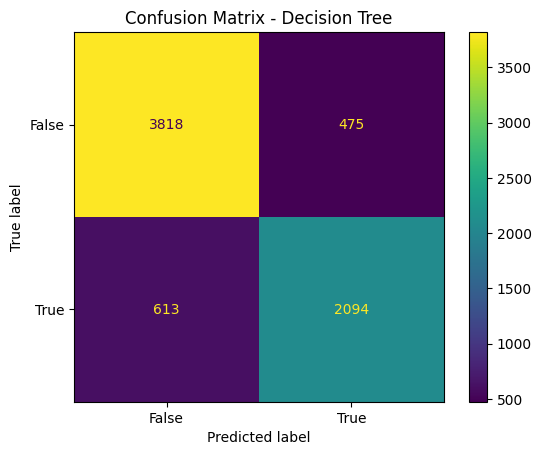

In [173]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(confusion_matrix(y_test, dt_y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, dt_y_pred)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

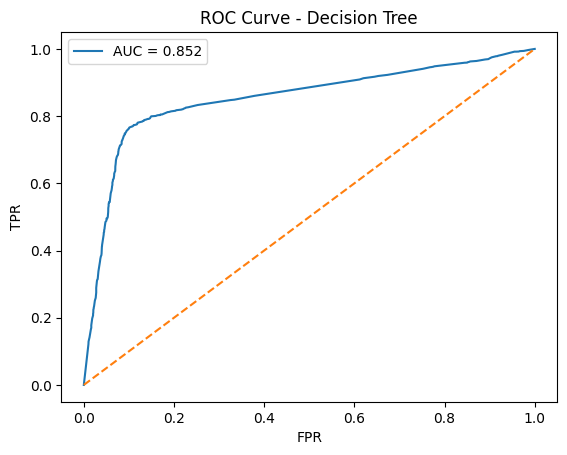

In [174]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# AUC
auc_value = roc_auc_score(y_test, dt_y_prob)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, dt_y_prob)
    
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

RANDOM FOREST


In [175]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring=scoring,
    refit="f1",  
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.-

In [176]:
rf_results = pd.DataFrame(rf_grid.cv_results_)

rf_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_leaf",
        "mean_test_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_roc_auc",
        "rank_test_f1"
    ]
].sort_values("rank_test_f1").head(10)

,param_n_estimators,param_max_depth,param_min_samples_leaf,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,rank_test_f1
50,200,20,2,0.832571,0.815799,0.732403,0.771794,0.857026,1
47,200,20,1,0.832214,0.815715,0.731295,0.771149,0.856510,2
46,100,20,1,0.831393,0.813805,0.731295,0.770306,0.855393,3
49,100,20,2,0.830679,0.811958,0.731480,0.769581,0.856157,4
53,200,20,5,0.830357,0.812660,0.729448,0.768772,0.857018,5
38,200,15,5,0.830429,0.815436,0.725753,0.767927,0.856959,6
35,200,15,2,0.829857,0.814692,0.724829,0.767107,0.856533,7
32,200,15,1,0.829536,0.815640,0.722428,0.766172,0.856410,8
34,100,15,2,0.828964,0.812754,0.724552,0.766099,0.855847,9
55,100,20,10,0.828679,0.812396,0.724183,0.765709,0.856113,10


In [177]:
final_rf = rf_grid.best_estimator_
final_rf.fit(X_train, y_train)

rf_y_pred = final_rf.predict(X_test)
rf_y_prob = final_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_y_pred))
print("Precision:", precision_score(y_test, rf_y_pred))
print("Recall:", recall_score(y_test, rf_y_pred))
print("F1:", f1_score(y_test, rf_y_pred))
print("AUC:", roc_auc_score(y_test, rf_y_prob))


Accuracy: 0.8315714285714285
Precision: 0.8141447368421053
Recall: 0.731437015145918
F1: 0.7705779334500875
AUC: 0.853770035343315


[[3841  452]
 [ 727 1980]]


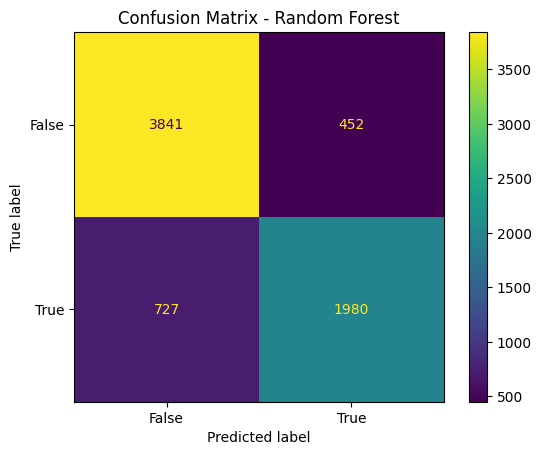

In [178]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(confusion_matrix(y_test, rf_y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, rf_y_pred)
plt.title("Confusion Matrix - Random Forest")
plt.show()

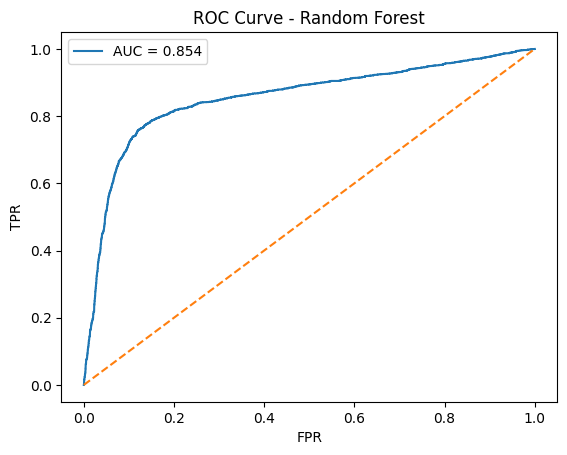

In [179]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# AUC
auc_value = roc_auc_score(y_test, rf_y_prob)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, rf_y_prob)
    
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

KNN

In [180]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif)),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'select__k': [10, 15, 20, 'all'],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

knn_grid.fit(X_train, y_train)

c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [20] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance'], 'select__k': [10, 15, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more 

In [181]:
knn_results = pd.DataFrame(knn_grid.cv_results_)
knn_results[
    [
        "param_select__k",
        "param_knn__n_neighbors",
        "param_knn__weights",
        "mean_test_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_roc_auc",
        "rank_test_f1"
    ]
].sort_values("rank_test_f1").head(10)

,param_select__k,param_knn__n_neighbors,param_knn__weights,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,rank_test_f1
54,20,21,distance,0.797357,0.777838,0.666265,0.717669,0.833764,1
46,20,15,distance,0.796607,0.775001,0.668021,0.717444,0.831025,2
42,20,15,uniform,0.796179,0.774792,0.666820,0.716656,0.830385,3
50,20,21,uniform,0.796286,0.776445,0.664510,0.716065,0.833019,4
34,20,11,uniform,0.794036,0.769994,0.666450,0.714389,0.825609,5
38,20,11,distance,0.793679,0.769121,0.666543,0.714073,0.826285,6
53,15,21,distance,0.793464,0.769503,0.664973,0.713381,0.830883,7
26,20,9,uniform,0.791607,0.765109,0.665343,0.711662,0.822446,8
30,20,9,distance,0.791536,0.765071,0.665158,0.711545,0.823032,9
49,15,21,uniform,0.791893,0.767827,0.661832,0.710833,0.830242,10


In [182]:
final_knn = knn_grid.best_estimator_
final_knn.fit(X_train, y_train)

knn_y_pred = final_knn.predict(X_test)
knn_y_prob = final_knn.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, knn_y_pred))
print("Precision:", precision_score(y_test, knn_y_pred))
print("Recall:", recall_score(y_test, knn_y_pred))
print("F1:", f1_score(y_test, knn_y_pred))
print("AUC:", roc_auc_score(y_test, knn_y_prob))


c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [20] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Accuracy: 0.7904285714285715
Precision: 0.7649572649572649
Recall: 0.6612486147026229
F1: 0.7093322765999603
AUC: 0.8284542555208172


[[3743  550]
 [ 917 1790]]


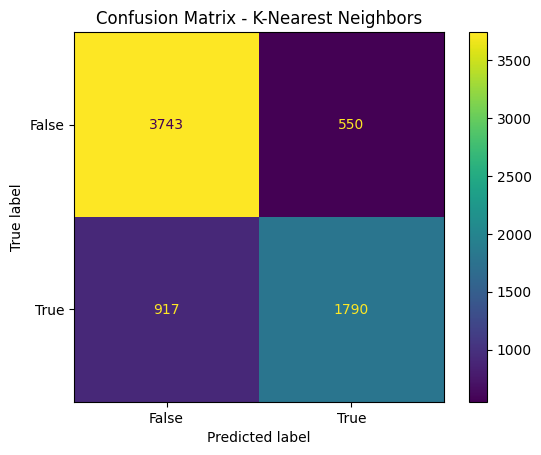

In [183]:
print(confusion_matrix(y_test, knn_y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, knn_y_pred)
plt.title("Confusion Matrix - K-Nearest Neighbors")
plt.show()

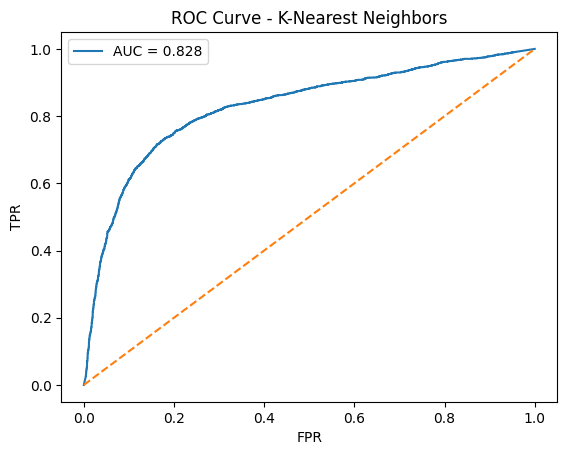

In [184]:
# AUC
auc_value = roc_auc_score(y_test, knn_y_prob)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, knn_y_prob)
    
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - K-Nearest Neighbors")
plt.legend()
plt.show()

In [185]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif)),
    ('svc', SVC(probability=False, random_state=42))
])

param_grid = {
    'select__k': [10, 20, 'all'],
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 0.01, 0.1],
    'svc__kernel': ['rbf']
}

svm_grid = GridSearchCV(
    pipe,
    param_grid,
    scoring=scoring,
    refit="f1",   # still choose best model by F1
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

svm_grid.fit(X_train, y_train)

c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [20] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'select__k': [10, 20, ...], 'svc__C': [0.1, 1, ...], 'svc__gamma': ['scale', 0.01, ...], 'svc__kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher

In [186]:
svm_results = pd.DataFrame(svm_grid.cv_results_)
svm_results[
    [
        "param_select__k",
        "param_svc__C",
        "param_svc__gamma",
        "param_svc__kernel",
        "mean_test_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_roc_auc",
        "rank_test_f1"
    ]
].sort_values("rank_test_f1").head(10)

,param_select__k,param_svc__C,param_svc__gamma,param_svc__kernel,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,rank_test_f1
15,20,10.0,scale,rbf,0.809286,0.793909,0.684463,0.735104,0.837231,1
14,20,1.0,0.1,rbf,0.806179,0.788305,0.681784,0.731175,0.839595,2
12,20,1.0,scale,rbf,0.803107,0.786100,0.674209,0.725853,0.839454,3
17,20,10.0,0.1,rbf,0.800714,0.778340,0.677535,0.724429,0.829409,4
16,20,10.0,0.01,rbf,0.798571,0.781444,0.665065,0.718532,0.837846,5
11,20,0.1,0.1,rbf,0.793893,0.767479,0.669868,0.715334,0.834820,6
9,20,0.1,scale,rbf,0.789929,0.766202,0.657213,0.707511,0.834864,7
25,all,10.0,0.01,rbf,0.787071,0.762517,0.652502,0.703211,0.825667,8
21,all,1.0,scale,rbf,0.787571,0.765446,0.649639,0.702793,0.830887,9
13,20,1.0,0.01,rbf,0.786464,0.762380,0.650470,0.701962,0.835158,10


In [187]:
final_svm = svm_grid.best_estimator_
final_svm.fit(X_train, y_train)

svm_y_pred = final_svm.predict(X_test)
svm_y_prob = final_svm.decision_function(X_test)

print("Accuracy:", accuracy_score(y_test, svm_y_pred))
print("Precision:", precision_score(y_test, svm_y_pred))
print("Recall:", recall_score(y_test, svm_y_pred))
print("F1:", f1_score(y_test, svm_y_pred))
print("AUC:", roc_auc_score(y_test, svm_y_prob))

c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [20] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Accuracy: 0.8054285714285714
Precision: 0.7877620881471973
Recall: 0.6800886590321389
F1: 0.7299762093576526
AUC: 0.8363594965765438


[[3797  496]
 [ 866 1841]]


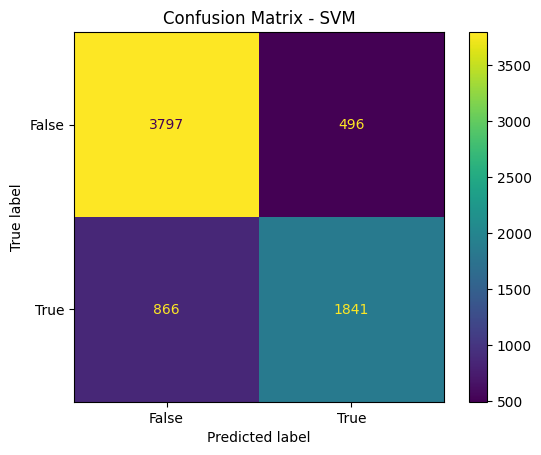

In [188]:
print(confusion_matrix(y_test, svm_y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, svm_y_pred)
plt.title("Confusion Matrix - SVM")
plt.show()

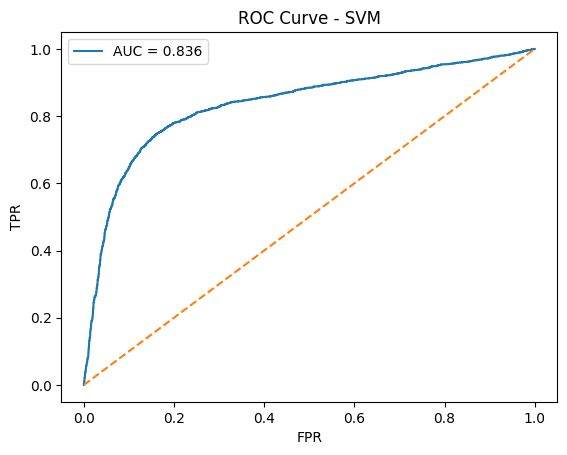

In [189]:
# AUC
auc_value = roc_auc_score(y_test, svm_y_prob)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, svm_y_prob)
    
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

In [190]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV

nn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif)),
    ("nn", MLPClassifier(
        random_state=42,
        max_iter=500,
        early_stopping=True,
        n_iter_no_change=15
    ))
])

nn_param_grid = {
    "select__k": [20, 30, "all"],
    "nn__hidden_layer_sizes": [
        (32,),
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32)
    ],
    "nn__activation": ["relu", "tanh"],
    "nn__alpha": [0.0001, 0.001, 0.01],
    "nn__learning_rate_init": [0.0005, 0.001, 0.005]
}

nn_grid = GridSearchCV(
    nn_pipe,
    nn_param_grid,
    scoring=scoring,
    refit="f1",
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

nn_grid.fit(X_train, y_train)

c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [20] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'nn__activation': ['relu', 'tanh'], 'nn__alpha': [0.0001, 0.001, ...], 'nn__hidden_layer_sizes': [(32,), (64,), ...], 'nn__learning_rate_init': [0.0005, 0.001, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",

In [191]:
nn_results = pd.DataFrame(nn_grid.cv_results_)

nn_results[
    [
        "param_select__k",
        "param_nn__hidden_layer_sizes",
        "param_nn__activation",
        "param_nn__alpha",
        "param_nn__learning_rate_init",
        "mean_test_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_roc_auc",
        "rank_test_f1"
    ]
].sort_values("rank_test_f1").head(10)

,param_select__k,param_nn__hidden_layer_sizes,param_nn__activation,param_nn__alpha,param_nn__learning_rate_init,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,rank_test_f1
306,20,"(128, 64)",tanh,0.0100,0.0005,0.820000,0.797646,0.716146,0.754700,0.847083,1
198,20,"(128, 64)",tanh,0.0001,0.0005,0.818143,0.794470,0.714483,0.752356,0.846859,2
309,20,"(128, 64)",tanh,0.0100,0.0010,0.819107,0.799732,0.710049,0.752154,0.846862,3
252,20,"(128, 64)",tanh,0.0010,0.0005,0.817893,0.794081,0.714206,0.752028,0.846868,4
303,20,"(64, 32)",tanh,0.0100,0.0050,0.817857,0.794561,0.713466,0.751756,0.846152,5
255,20,"(128, 64)",tanh,0.0010,0.0010,0.818036,0.796871,0.710511,0.751197,0.845147,6
201,20,"(128, 64)",tanh,0.0001,0.0010,0.818000,0.797034,0.710142,0.751064,0.845085,7
318,20,"(128, 64, 32)",tanh,0.0100,0.0010,0.817143,0.793290,0.713006,0.750945,0.847428,8
312,20,"(128, 64)",tanh,0.0100,0.0050,0.817357,0.794477,0.711712,0.750786,0.844331,9
204,20,"(128, 64)",tanh,0.0001,0.0050,0.817143,0.794275,0.711342,0.750461,0.844011,10


In [192]:
final_nn = nn_grid.best_estimator_
final_nn.fit(X_train, y_train)

nn_y_pred = final_nn.predict(X_test)
nn_y_prob = final_nn.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, nn_y_pred))
print("Precision:", precision_score(y_test, nn_y_pred))
print("Recall:", recall_score(y_test, nn_y_pred))
print("F1:", f1_score(y_test, nn_y_pred))
print("AUC:", roc_auc_score(y_test, nn_y_prob))

c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [20] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\minhp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Accuracy: 0.8185714285714286
Precision: 0.7941056078591895
Recall: 0.7166605097894349
F1: 0.7533980582524272
AUC: 0.8460253205555972


[[3790  503]
 [ 767 1940]]


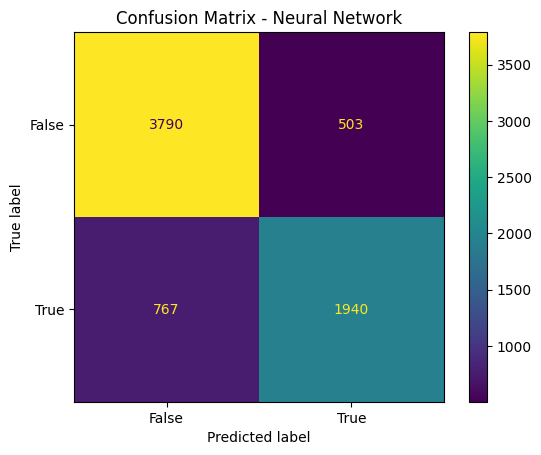

In [193]:
print(confusion_matrix(y_test, nn_y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, nn_y_pred)
plt.title("Confusion Matrix - Neural Network")
plt.show()

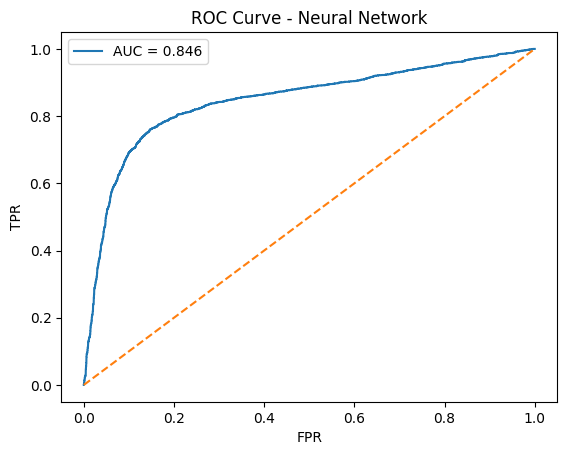

In [194]:
# AUC
auc_value = roc_auc_score(y_test, nn_y_prob)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, nn_y_prob)
    
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Neural Network")
plt.legend()
plt.show()

In [197]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "DT": dt_grid.best_estimator_,
    "RF": rf_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
    "NN": nn_grid.best_estimator_
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    # for ROC AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False, ignore_index=True)
print(results_df)

  Model  Accuracy  Precision    Recall        F1       AUC
0    DT  0.844571   0.815103  0.773550  0.793783  0.851751
1    RF  0.831571   0.814145  0.731437  0.770578  0.853770
2    NN  0.818571   0.794106  0.716661  0.753398  0.846025
3   SVM  0.805429   0.787762  0.680089  0.729976  0.836359
4   KNN  0.790429   0.764957  0.661249  0.709332  0.828454


In [ ]:
# load unknown dataset
unknown_df = pd.read_csv("unknown_dataset.csv")

# apply SAME preprocessing used during training
unknown_df = unknown_df.drop(columns=['application_date', 'application_year'])

numeric_cols = unknown_df.select_dtypes(include=['int64', 'float64']).columns
unknown_df[numeric_cols] = unknown_df[numeric_cols].fillna(unknown_df[numeric_cols].median())

categorical_cols = unknown_df.select_dtypes(include=['str', 'datetime64']).columns
unknown_df[categorical_cols] = unknown_df[categorical_cols].fillna('Unknown')   

#Binning
unknown_df = apply_binning(unknown_df)

# feature engineering
unknown_df = add_features(unknown_df)

# log transformation
unknown_df[['income', 'account_balance', 'loan_amount']] = log_transformer.transform(
    unknown_df[['income', 'account_balance', 'loan_amount']]
)

# one-hot encoding
unknown_df = pd.get_dummies(
    unknown_df,
    columns=[
        'gender', 'employment_status', 'education_level',
        'loan_purpose', 'region', 'marital_status',
        'credit_category', 'debt_to_income_category'
    ],
    drop_first=True
)

# align columns with training data
unknown_df = unknown_df.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
# apply model
models = {
    "DT": final_dt,
    "RF": final_rf,
    "KNN": final_knn,
    "SVM": final_svm,
    "NN": final_nn
}

for model_name, model in models.items():
    predictions = model.predict(unknown_df)
    submission = pd.DataFrame({
        "row ID": [f"Row{i}" for i in range(len(predictions))],
        "Predicted-Loan-Default": predictions.astype(int)
    })
    submission.to_csv(f"submission_{model_name}.csv", index=False)
    "Predicted-Loan-Default": predictions_nn.astype(int)
